## Semi-Supervised Learning

Most times, manually labeling a complete dataset can be very time consuming, and in
real life scenarios, time is money. 

We are aiming to partially delete the target feature in
different proportions for each class, and run active and pasive semi-supervised learning
processes. This experiment will help us understand how it performs with our samples.


Our set of samples is not as large as we would like it to be, but it will be useful to study
how to identify the most interesting samples to manually label and leave the rest to the
model, saving the time and effort it takes to fully supervise a dataset

In a production scenario, a holdout test scenario creation using a split would be the way to go, but as this is a experiment to check the self training, we will save the true labels and directly use the unlabeled samples as our test set, and check how well the models *self train*.

### Production Ideal Split

```text
Full dataset (5000)
|-- Test set (20%, 1000 samples) - fully labeled, not seen during training
`-- Train pool (80%, 4000 samples)
    |-- Labeled portion (e.g., 1% of 4000 = 40 samples)
    `-- Unlabeled portion (masked as NaN, 3960 samples)
```

### Experimental Split

```text
Full dataset (5000)
|-- Test set (1 - label ratio % of samples) - unlabeled labeled, the labels we want to predict
`-- Train set - fully labeled (% defined by label_ratio hyperparameter)

```

In [275]:
import pandas
import numpy as np


In [276]:
data = pandas.read_csv("../data/updated_pollution_dataset.csv")

In [277]:
target_col = data.columns[-1]

distribution = (
    data[target_col]
    .value_counts(dropna=False)
    .rename_axis(target_col)
    .reset_index(name="count")
)

distribution["percentage"] = (distribution["count"] / len(data) * 100).round(2)
distribution

,Air Quality,count,percentage
0,Good,2000,40.0
1,Moderate,1500,30.0
2,Poor,1000,20.0
3,Hazardous,500,10.0


In [ ]:
quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)


data[target_col] = data[target_col].astype("int8")
data[[target_col]].head()


,Air Quality
0,2
1,2
2,2
3,3
4,3


## Target variable partial deletion

### Label Ratio
`label_ratio` controls the proportion of samples that remain labeled and are used as the supervised baseline before applying semi-supervised learning by masking the target feature, which we previously saved in a new column we will use when evaluating the predictions.

In [279]:
label_ratio = 0.01 # % of the data will be labeled
RANDOM_STATE = 42

data["true_label"] = data[target_col] # true labels persistency for evaluation



### 1. Pasive Semi-Supervision

In this strategy, we ignore the class distribution and pseudo-randomly mask target samples

In [280]:
def passive_mask(data, target, label_ratio=0.1, random_state=42):
    data = data.copy(deep=True)
    unlabeled_idx = data.sample(frac=1 - label_ratio, random_state=random_state).index
    data.loc[unlabeled_idx, target] = np.nan
    return data

### 2. Active Semi-Supervision

In active semi-supervised learning, we respect the original class distribution proportions and keep the original imbalance for each class, essentially mantaining the distribution with a different amount of supervised samples.

In [281]:
def active_mask(data, target, label_ratio, random_state=42):
    
    data = data.copy(deep=True)

    unlabeled_idx = (
        data.groupby(target, group_keys=False)          # group by class
          .apply(lambda g: g.sample(                  # from each class
              frac=1 - label_ratio,                 # mask this fraction
              random_state=random_state
          ))
          .index
    )
    data.loc[unlabeled_idx, target] = np.nan
    return data

In [282]:
data_passive = passive_mask(data, target_col, label_ratio=label_ratio, random_state=RANDOM_STATE)
data_active  = active_mask(data,  target_col, label_ratio=label_ratio, random_state=RANDOM_STATE)

In [283]:
for name, data in [("Passive", data_passive), ("Active", data_active)]:
    labeled   = data[target_col].notna()
    print(f"\n{'─'*40}")
    print(f"{name} - Labeled: {labeled.sum()} | Unlabeled: {(~labeled).sum()}")
    print("Label distribution (labeled only):")
    print(data.loc[labeled, target_col].value_counts(normalize=True).sort_index())


────────────────────────────────────────
Passive - Labeled: 50 | Unlabeled: 4950
Label distribution (labeled only):
Air Quality
0.0    0.12
1.0    0.18
2.0    0.34
3.0    0.36
Name: proportion, dtype: float64

────────────────────────────────────────
Active - Labeled: 50 | Unlabeled: 4950
Label distribution (labeled only):
Air Quality
0.0    0.1
1.0    0.2
2.0    0.3
3.0    0.4
Name: proportion, dtype: float64


As in the passive (random) masking the amount of masks per class is random, we have a bigger amount of labeled samples form the minority class, comparing it to the active masking, even if the difference is too small to make any difference, the dataset is still imbalanced.

Quality map for help:

```python
quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}
```

In [284]:
data_active.head()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality,true_label
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,NaN,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,NaN,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,NaN,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,NaN,3
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,NaN,3


In [285]:
data_passive.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality,true_label
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,NaN,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,NaN,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,NaN,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,NaN,3
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,NaN,3


We will use the active labeled dataset (with defined proportions) for the baseline, and then we will compare active and pasive masking for different values of the label_ratio.

### Data Split for Training and Evaluation

In [286]:
# Labeled pool, train supervised component
labeled_data = data_active[data_active[target_col].notna()]

# Unlabeled pool, semi-supervised propagation / pseudo-labeling
unlabeled_data = data_active[data_active[target_col].isna()]

# Ground truth, used for final evaluation (using it during training would be cheating)
y_true_unlabeled = data_active.loc[unlabeled_data.index, "true_label"]

### Feature Preparation

In [287]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in data.columns if c not in [target_col, "true_label"]]

scaler = StandardScaler()

def prepare_xy(df):
    labeled   = df[df[target_col].notna()]
    unlabeled = df[df[target_col].isna()]
    X_lab   = scaler.fit_transform(labeled[feature_cols])
    y_lab   = labeled[target_col].astype(int).values
    X_unlab = scaler.transform(unlabeled[feature_cols])
    y_true  = df.loc[unlabeled.index, "true_label"].astype(int).values
    return X_lab, y_lab, X_unlab, y_true

X_lab, y_lab, X_unlab, y_true = prepare_xy(data_active)

### Supervised Baseline (Labeled Data Only)

In [288]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
clf_base.fit(X_lab, y_lab)

y_pred_base = clf_base.predict(X_unlab)
print("=== Supervised Baseline (labeled only) ===")
print(classification_report(y_true, y_pred_base,
      target_names=["3","2","1","0"]))

=== Supervised Baseline (labeled only) ===
              precision    recall  f1-score   support

           3       0.81      0.63      0.71       495
           2       0.70      0.76      0.73       990
           1       0.89      0.88      0.88      1485
           0       0.98      1.00      0.99      1980

    accuracy                           0.88      4950
   macro avg       0.85      0.82      0.83      4950
weighted avg       0.88      0.88      0.88      4950



## Semi-Supervised Models

### Label Spreading (Passive vs Active Masking)

In [289]:
from sklearn.semi_supervised import LabelSpreading

results = {}

for name, df in [("Passive", data_passive), ("Active", data_active)]:
    X_lab_i, y_lab_i, X_unlab_i, y_true_i = prepare_xy(df)

    # Build full X and y (-1 marks unlabeled)
    X_all = np.vstack([X_lab_i, X_unlab_i])
    y_all = np.concatenate([y_lab_i, np.full(len(X_unlab_i), -1)])

    ls = LabelSpreading(kernel="knn", n_neighbors=7, max_iter=100)
    ls.fit(X_all, y_all)

    n_unlab = len(X_unlab_i)
    y_pred  = ls.transduction_[-n_unlab:]
    results[f"LabelSpreading_{name}"] = (y_true_i, y_pred)
    print(f"\n=== Label Spreading — {name} ===")
    print(classification_report(y_true_i, y_pred,
          target_names=["3","2","1","0"]))


=== Label Spreading — Passive ===
              precision    recall  f1-score   support

           3       0.54      0.47      0.50       494
           2       0.49      0.38      0.43       991
           1       0.74      0.85      0.79      1483
           0       0.97      1.00      0.98      1982

    accuracy                           0.78      4950
   macro avg       0.69      0.68      0.68      4950
weighted avg       0.76      0.78      0.77      4950


=== Label Spreading — Active ===
              precision    recall  f1-score   support

           3       0.77      0.57      0.66       495
           2       0.71      0.60      0.65       990
           1       0.77      0.90      0.83      1485
           0       0.97      1.00      0.99      1980

    accuracy                           0.85      4950
   macro avg       0.81      0.77      0.78      4950
weighted avg       0.84      0.85      0.84      4950



### Self-Training with Pseudo-Labels

In [290]:
from sklearn.semi_supervised import SelfTrainingClassifier

for name, df in [("Passive", data_passive), ("Active", data_active)]:
    X_lab_i, y_lab_i, X_unlab_i, y_true_i = prepare_xy(df)

    X_all = np.vstack([X_lab_i, X_unlab_i])
    y_all = np.concatenate([y_lab_i, np.full(len(X_unlab_i), -1)])

    base_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    st = SelfTrainingClassifier(base_clf, threshold=0.8, verbose=False)
    st.fit(X_all, y_all)

    n_unlab = len(X_unlab_i)
    y_pred  = st.transduction_[-n_unlab:]
    labeled_mask = y_pred != -1
    n_unlabeled_remaining = (~labeled_mask).sum()
    if n_unlabeled_remaining > 0:
        print(f"{n_unlabeled_remaining} samples could not be pseudo-labeled (kept as -1)")

    y_pred_clean  = y_pred[labeled_mask]
    y_true_clean  = y_true_i[labeled_mask]

    results[f"SelfTraining_{name}"] = (y_true_clean, y_pred_clean)

    print(f"\n=== Self-Training — {name} ===")
    print(classification_report(
        y_true_clean, y_pred_clean,
        labels=[0, 1, 2, 3],
        target_names=["3","2","1","0"]
    ))

613 samples could not be pseudo-labeled (kept as -1)

=== Self-Training — Passive ===
              precision    recall  f1-score   support

           3       0.67      0.41      0.51       390
           2       0.65      0.72      0.68       736
           1       0.91      0.95      0.93      1289
           0       1.00      1.00      1.00      1922

    accuracy                           0.89      4337
   macro avg       0.81      0.77      0.78      4337
weighted avg       0.88      0.89      0.88      4337

890 samples could not be pseudo-labeled (kept as -1)

=== Self-Training — Active ===
              precision    recall  f1-score   support

           3       0.93      0.56      0.70       207
           2       0.67      0.63      0.65       735
           1       0.77      0.83      0.80      1142
           0       0.98      1.00      0.99      1976

    accuracy                           0.86      4060
   macro avg       0.84      0.75      0.78      4060
weighted avg  

### Metric Comparison

In [291]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

rows = [("Baseline (supervised)", y_true, y_pred_base)]
for k, (yt, yp) in results.items():
    rows.append((k, yt, yp))

summary = pd.DataFrame([{
    "Model": name,
    "Accuracy": accuracy_score(yt, yp),
    "Macro F1": f1_score(yt, yp, average="macro"),
} for name, yt, yp in rows])

print(summary.to_string(index=False))

                 Model  Accuracy  Macro F1
 Baseline (supervised)  0.879192  0.829117
LabelSpreading_Passive  0.778182  0.676906
 LabelSpreading_Active  0.845253  0.780762
  SelfTraining_Passive  0.885405  0.780459
   SelfTraining_Active  0.861330  0.782904


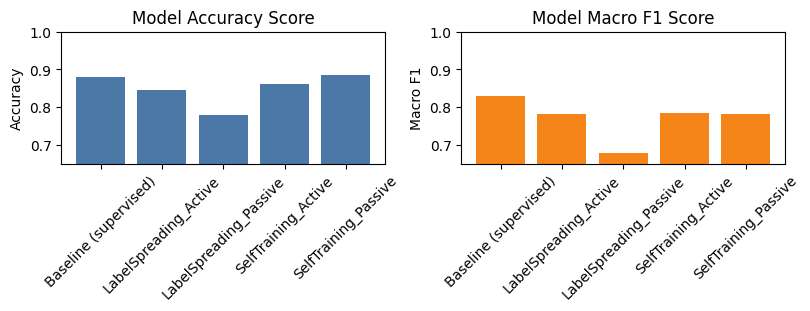

In [ ]:
import matplotlib.pyplot as plt

plot_df = summary.copy()
plot_df = plot_df.sort_values("Model")

fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

axes[0].bar(plot_df["Model"], plot_df["Accuracy"], color="#4C78A8")
axes[0].set_title("Model Accuracy Score")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.65, 1)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(plot_df["Model"], plot_df["Macro F1"], color="#F58518")
axes[1].set_title("Model Macro F1 Score")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0.65, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.show()

## Comparison Across Label Ratios

* ### 1% labeled samples (50 labeled - 4950 masked/unlabeled)

***The plot starts at 0.6 to keep passive label spreading F1 score visible, other plots use a higher lower-bound values as their results are stronger.***

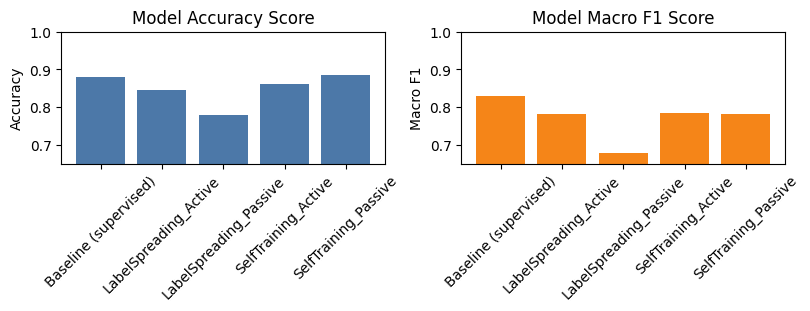

613 not pseudo-labeled in passive and kept as -1, 890 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.879192 | 0.829117 |
| **LabelSpreading_Passive** | 0.778182 | 0.676906 |
| **LabelSpreading_Active** | 0.845253 | 0.780762 |
| **SelfTraining_Passive** | 0.885405 | 0.780459 |
| **SelfTraining_Active** | 0.861330 | 0.782904 |

* ### 10% labeled samples (500 labeled - 4500 masked/unlabeled)
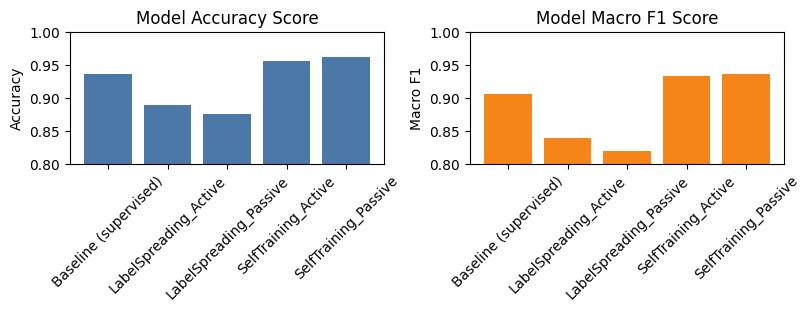

376 not pseudo-labeled in passive and kept as -1, 336 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.936000 | 0.905001 |
| **LabelSpreading_Passive** | 0.875778 | 0.818342 |
| **LabelSpreading_Active** | 0.888444 | 0.838311 |
| **SelfTraining_Passive** | 0.961445 | 0.936357 |
| **SelfTraining_Active** | 0.955331 | 0.932248 |

* ### 30% labeled samples (1500 labeled - 3500 masked/unlabeled)
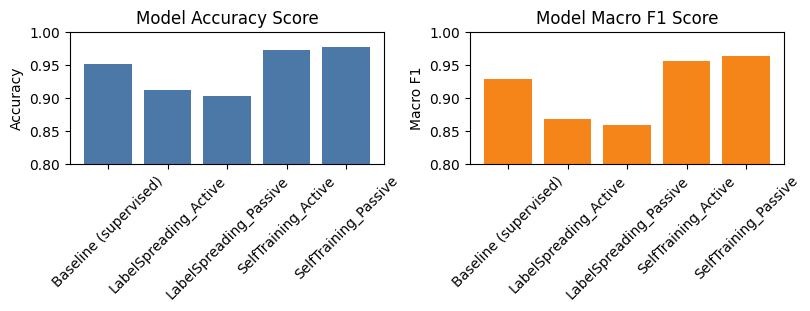

328 not pseudo-labeled in passive and kept as -1, 290 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.951429 | 0.928896 |
| **LabelSpreading_Passive** | 0.902857 | 0.858268 |
| **LabelSpreading_Active** | 0.911429 | 0.867664 |
| **SelfTraining_Passive** | 0.976671 | 0.963484 |
| **SelfTraining_Active** | 0.972586 | 0.955854 |

* ### 50% labeled samples (2500 labeled - 2500 masked/unlabeled)
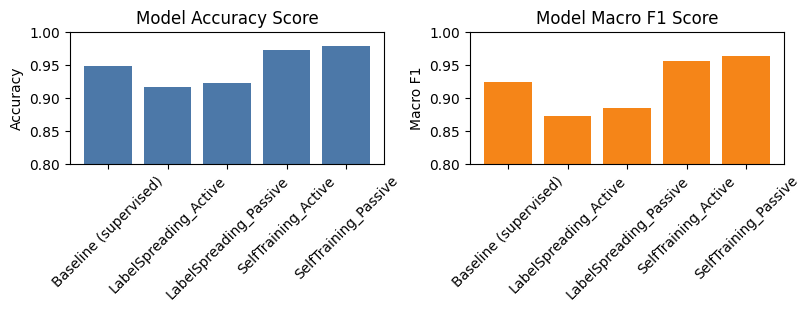

254 not pseudo-labeled in passive and kept as -1, 212 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.948400 | 0.923514 |
| **LabelSpreading_Passive** | 0.922000 | 0.884088 |
| **LabelSpreading_Active** | 0.916400 | 0.872633 |
| **SelfTraining_Passive** | 0.977738 | 0.963728 |
| **SelfTraining_Active** | 0.972902 | 0.955833 |

* ### 70% labeled samples (3500 labeled - 1500 masked/unlabeled)
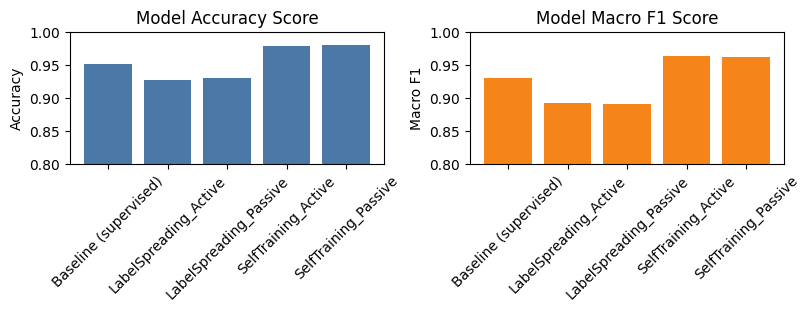

162 not pseudo-labeled in passive and kept as -1, 140 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.951333 | 0.929895 |
| **LabelSpreading_Passive** | 0.930000 | 0.889807 |
| **LabelSpreading_Active** | 0.927333 | 0.891415 |
| **SelfTraining_Passive** | 0.979073 | 0.962329 |
| **SelfTraining_Active** | 0.977941 | 0.963222 |

* ### 90% labeled samples (4500 labeled - 500 masked/unlabeled)
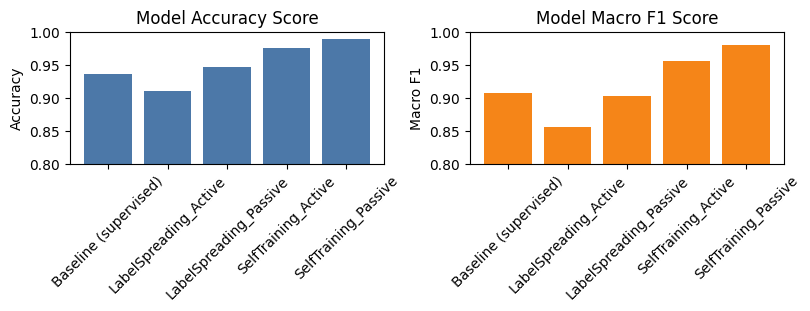

54 not pseudo-labeled in passive and kept as -1, 62 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.936000 | 0.906667 |
| **LabelSpreading_Passive** | 0.946000 | 0.902780 |
| **LabelSpreading_Active** | 0.910000 | 0.855680 |
| **SelfTraining_Passive** | 0.988789 | 0.979887 |
| **SelfTraining_Active** | 0.974886 | 0.955470 |

* ### 99% labeled samples (4950 labeled - 50 masked/unlabeled)
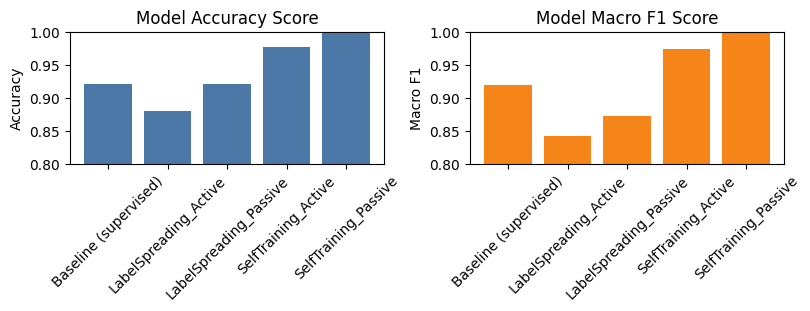

9 not pseudo-labeled in passive and kept as -1, 6 in active

| Model | Accuracy | Macro F1 |
| :--- | :--- | :--- |
| **Baseline (supervised)** | 0.920000 | 0.918831 |
| **LabelSpreading_Passive** | 0.920000 | 0.871943 |
| **LabelSpreading_Active** | 0.880000 | 0.841340 |
| **SelfTraining_Passive** | 1.000000 | 1.000000 |
| **SelfTraining_Active** | 0.977273 | 0.974425 |

## Conclusions and Takeaways

### Key features

1. **Self-training was consistently the strongest approach** comparing it to **label spreading** across all ratios, specially when labeled data was low (1 to 10%), reaching the best accuracy and macro F1 in almost every train/test distribution.

2. **Passive masking usually matched or outperformed active masking** for self training, this tells us that mantaining the original proportions in labeled samples worked well for our problem.

3. **Active masking helped label spreading in low labeled sample proportion sets**, but this advantage was not mantained as the labeled sample ammount increased, still underperforming against self training.

4. **More labeled data generally improved all methods**, but we need to take into account that those cases leave us with smaller test sets, with less samples to miss, and probably the majority of the set being part of the majority class, but good scores in macro f1 tell us that if a test sample was part of the minority class, it was correclty predicted too, therefore it worked well overall, even if we should take those metrics carefully.


### Conclusion Summary

If labeling budget is limited, using 30%-50% labeled data already provides strong performance. Therefore full dataset labeling can be avoided with small accuracy and f1 score loss.
